In [95]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, roc_curve, roc_auc_score
from collections import Counter
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.metrics import PrecisionRecallDisplay

In [96]:
df_original = pd.read_csv('df.csv')
df_original['Malnurished'] = df_original[['Underweight', 'Stunting', 'Wasting']].max(axis=1)
df = df_original.drop(['Underweight', 'Stunting', 'Wasting'], axis = 1)
df.head()

,Child_age,BMI,Children_under5,Total_children_ever_born,Mother_age_current,Mother_education_1,Mother_education_2,Mother_education_3,Wealth_index_1,Wealth_index_2,...,Ethnicity_terai dalit,Ethnicity_newar,Ethnicity_hill janajati,Ethnicity_terai janajati,Child_sex_female,Father_education_1.0,Father_education_2.0,Father_education_3.0,Health_insurance_yes,Malnurished
0,17,22.00,1,1,34,1,0,0,0,0,...,0,0,0,0,1,0,1,0,0,0
1,40,25.10,2,2,26,0,1,0,1,0,...,0,0,1,0,0,1,0,0,0,1
2,59,25.10,2,2,26,0,1,0,1,0,...,0,0,1,0,1,1,0,0,0,1
3,55,21.53,1,1,28,0,1,0,1,0,...,0,0,1,0,1,1,0,0,0,1
4,14,28.03,1,1,26,1,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0


In [97]:
df.shape

(2205, 37)

**Train-test Split**

In [98]:
X = df.drop(columns=['Malnurished'])
y = df['Malnurished']

# Train-test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, stratify = y, random_state= 42)

In [99]:
print(y_train.value_counts())
print(y_test.value_counts())

Malnurished
0    1168
1     596
Name: count, dtype: int64
Malnurished
0    292
1    149
Name: count, dtype: int64


**Standard Scaler**

In [100]:
columns_to_scale = ['Child_age', 'BMI', 'Mother_age_current']
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[columns_to_scale] = scaler.fit_transform(X_train[columns_to_scale])
X_test_scaled[columns_to_scale] = scaler.transform(X_test[columns_to_scale])

**Visualize the PCA Results**

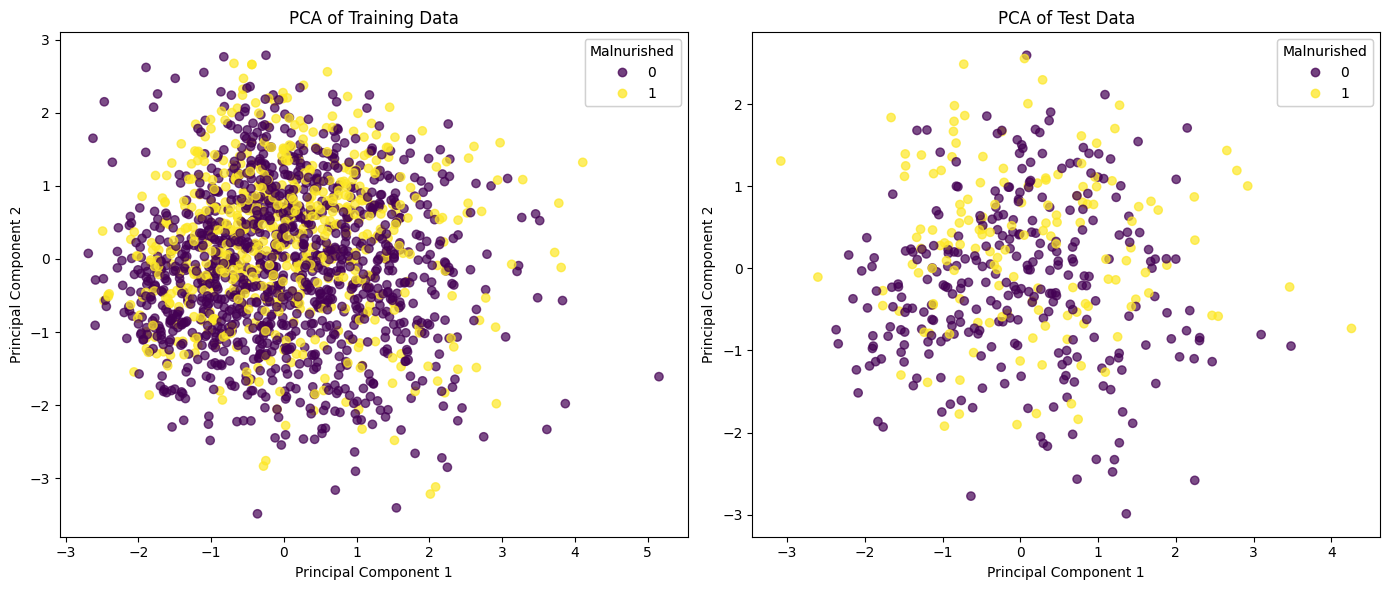

In [101]:
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)


fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot for training data
scatter_train = axes[0].scatter(X_train_pca[:, 0], X_train_pca[:, 1], 
                                c=y_train, cmap='viridis', alpha=0.7)
axes[0].set_title("PCA of Training Data")
axes[0].set_xlabel("Principal Component 1")
axes[0].set_ylabel("Principal Component 2")
legend1 = axes[0].legend(*scatter_train.legend_elements(), title="Malnurished")
axes[0].add_artist(legend1)

# Plot for test data
scatter_test = axes[1].scatter(X_test_pca[:, 0], X_test_pca[:, 1], 
                               c=y_test, cmap='viridis', alpha=0.7)
axes[1].set_title("PCA of Test Data")
axes[1].set_xlabel("Principal Component 1")
axes[1].set_ylabel("Principal Component 2")
legend2 = axes[1].legend(*scatter_test.legend_elements(), title="Malnurished")
axes[1].add_artist(legend2)

plt.tight_layout()
plt.show()

### Balancing using SMOTE

In [118]:
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train_scaled, y_train)
print('Before SMOTE: ', Counter(y_train))
print('After SMOTE: ', Counter(y_train_sm))

Before SMOTE:  Counter({0: 1168, 1: 596})
After SMOTE:  Counter({0: 1168, 1: 1168})


### Cross-validation for Best k

In [156]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
params = {'n_neighbors':range(1, 30),
          'weights':['uniform', 'distance'],
          'p':[1,2]}

knn = KNeighborsClassifier()
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
knn_grid_cv = GridSearchCV(knn, param_grid=params, scoring='recall', cv=cv) 
knn_grid_cv.fit(X_train_sm, y_train_sm)
print("Best Hyper Parameters:\n",knn_grid_cv.best_params_)

Best Hyper Parameters:
 {'n_neighbors': 28, 'p': 2, 'weights': 'distance'}


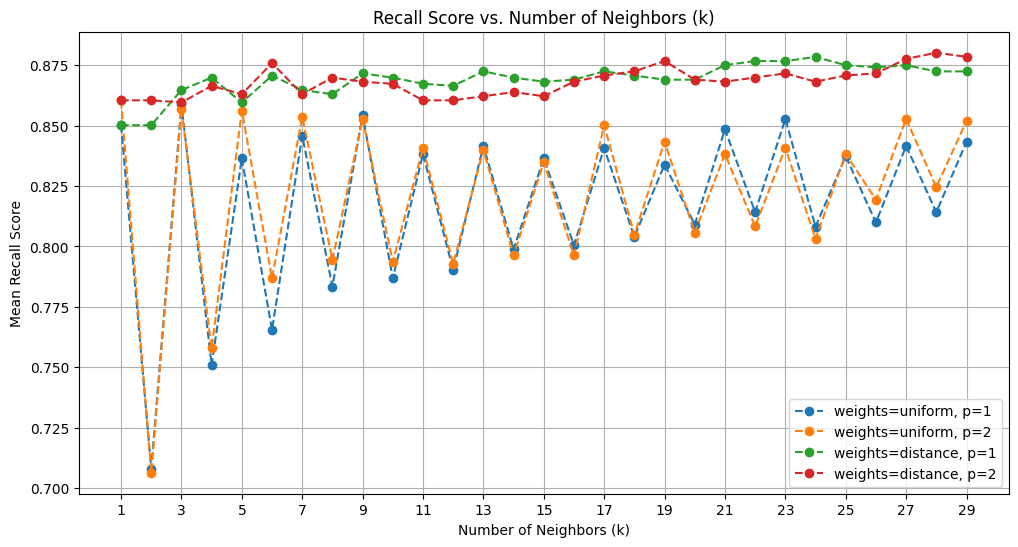

In [157]:
# Convert GridSearchCV results into DataFrame
results = pd.DataFrame(knn_grid_cv.cv_results_)

# Plotting mean recall score vs. n_neighbors
plt.figure(figsize=(12, 6))

# Extract mean recall scores for each k-value, grouped by weights and p
for weight in ['uniform', 'distance']:
    for p_value in [1, 2]:
        subset = results[
            (results['param_weights'] == weight) & 
            (results['param_p'] == p_value)
        ]
        plt.plot(
            subset['param_n_neighbors'], 
            subset['mean_test_score'],
            marker='o',
            linestyle='--',
            label=f'weights={weight}, p={p_value}'
        )

# Plot labeling
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Mean Recall Score')
plt.title('Recall Score vs. Number of Neighbors (k)')
plt.legend()
plt.grid()
plt.xticks(range(1, 30, 2))
plt.show()


### Model Fit

In [169]:
knn_combined = KNeighborsClassifier(n_neighbors=28, p= 2, weights = 'distance')
knn_combined.fit(X_train_sm, y_train_sm)
y_predict = knn_combined.predict(X_test_scaled)

print(accuracy_score(y_test, y_predict))
pd.crosstab(y_test, y_predict)

0.5238095238095238


col_0,0,1
Malnurished,,
0,125,167
1,43,106


#### Model's Performance

**Classification Report**

In [170]:
print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

           0       0.74      0.43      0.54       292
           1       0.39      0.71      0.50       149

    accuracy                           0.52       441
   macro avg       0.57      0.57      0.52       441
weighted avg       0.62      0.52      0.53       441



**ROC-AUC Score**

In [171]:
auc = roc_auc_score(y_test, knn_combined.predict_proba(X_test)[:,1])
print(f'ROC-AUC Score: {auc:.4f}')

ROC-AUC Score: 0.5385


**Average Precision**

In [172]:
average_precision_score(y_test, y_predict)

0.37373056260879844

Average Precision: 0.4402


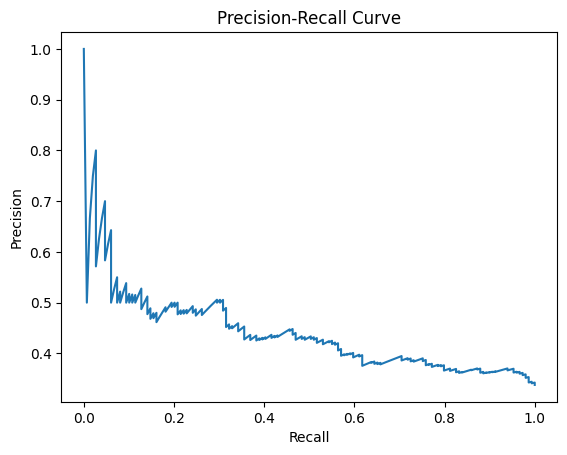

In [173]:
y_true = y_test  # True labels
y_scores = knn_combined.predict_proba(X_test_scaled)[:, 1]  # Probabilities for the positive class

# Get precision, recall, thresholds
precision, recall, thresholds = precision_recall_curve(y_true, y_scores)

# Compute Average Precision
ap = average_precision_score(y_true, y_scores)
print(f"Average Precision: {ap:.4f}")

# Plot Precision vs. Recall
plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()

ROC-AUC: 0.6090


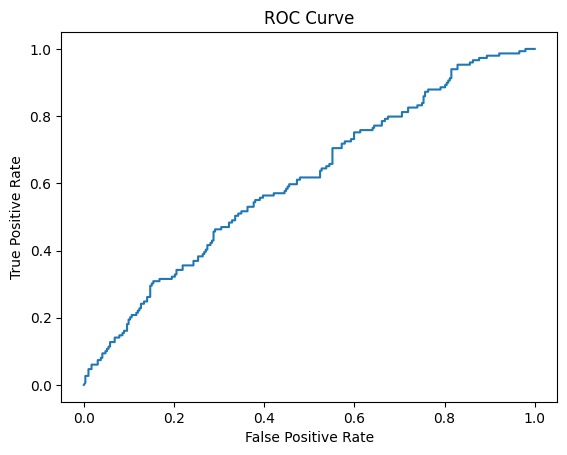

In [174]:
# Still using y_true and y_scores from above
fpr, tpr, thresholds = roc_curve(y_true, y_scores)

# Compute ROC-AUC
roc_auc = roc_auc_score(y_true, y_scores)
print(f"ROC-AUC: {roc_auc:.4f}")

# Plot ROC Curve
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

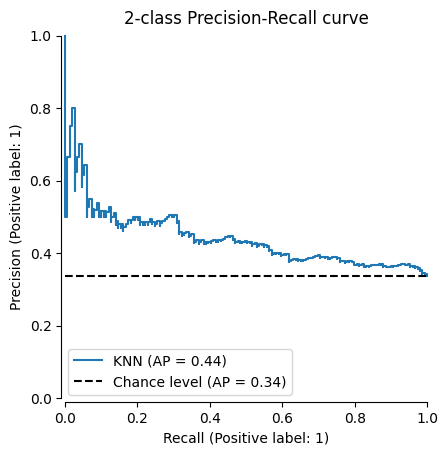

In [175]:
display = PrecisionRecallDisplay.from_estimator(
    knn_combined,         # trained model
    X_test_scaled,        # Test features
    y_test,               # True labels
    name="KNN",
    plot_chance_level=True,
    despine=True,
)

_ = display.ax_.set_title("2-class Precision-Recall curve")


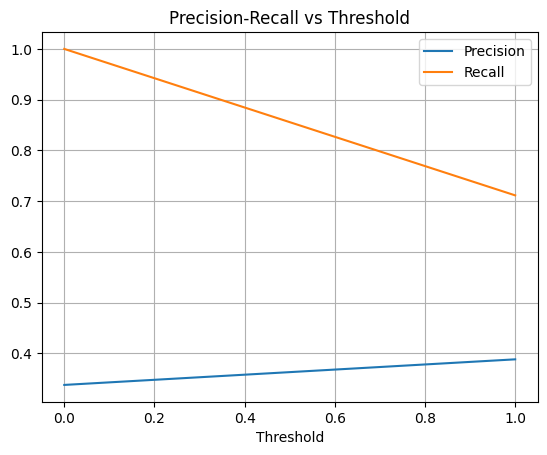

In [176]:
precisions, recalls, thresholds = precision_recall_curve(y_test, y_predict)

plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.xlabel('Threshold')
plt.legend()
plt.title('Precision-Recall vs Threshold')
plt.grid()
plt.show()

In [177]:
knn = KNeighborsClassifier(n_neighbors=5, weights = 'distance', metric = 'manhattan')
knn.fit(X_train_sm, y_train_sm)

y_predict = knn.predict_proba(X_test_scaled)[:, 1]  # Probabilities for class 1

# Apply custom threshold
y_pred_custom = (y_predict >= 0.30).astype(int)
print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       0.72      0.28      0.40       292
           1       0.36      0.79      0.49       149

    accuracy                           0.45       441
   macro avg       0.54      0.53      0.45       441
weighted avg       0.60      0.45      0.43       441



In [178]:
y_pred_recall_opt = (y_predict >= best_threshold).astype(int)

from sklearn.metrics import classification_report, confusion_matrix

print("Confusion Matrix at Optimized Recall Threshold:")
print(confusion_matrix(y_test, y_pred_recall_opt))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_recall_opt, digits=3))


NameError: name 'best_threshold' is not defined

In [ ]:
from sklearn.metrics import average_precision_score

# Compute average precision
ap_score = average_precision_score(y_test, y_predict)

print(f"Average Precision Score: {ap_score:.3f}")


Average Precision Score: 0.404


In [ ]:
from sklearn.metrics import make_scorer, recall_score

recall_scorer = make_scorer(recall_score, pos_label=1)

grid = GridSearchCV(knn, param_grid, scoring=recall_scorer, cv=5)
grid.fit(X_train_scaled, y_train)

print("Best k:", grid.best_params_['n_neighbors'])
print("Best Recall (class 1):", grid.best_score_)


Recall Score (threshold 0.3): 0.611


In [ ]:
from sklearn.feature_selection import SequentialFeatureSelector

selector = SequentialFeatureSelector(knn, n_features_to_select=5, direction='forward')
selector.fit(X_train_scaled, y_train)

selected_features = X_train.columns[selector.get_support()]
print("Sequentially selected:", list(selected_features))


Sequentially selected: ['Ethnicity_hill chhetri', 'Ethnicity_terai brahmin/chhetri', 'Ethnicity_hill dalit', 'Ethnicity_terai dalit', 'Father_education_3.0']


1. Feature Selection
2. Difference between Precision-Recall Curve and 2-Class Precision-Recall Curve